In [2]:
import xgi
import numpy as np
from had_model import HAD_model
import matplotlib.pyplot as plt

In [4]:
N = 300
ps = [1e-3, 1e-4, 1e-6]
seed = 0
H = xgi.fast_random_hypergraph(N, ps, seed=seed)
H.cleanup()
print(H)
xgi.unique_edge_sizes(H), xgi.is_connected(H)

Unnamed Hypergraph with 300 nodes and 791 hyperedges


([2, 3, 4], True)

In [6]:
epsilon = 0.1
Model = HAD_model(epsilon, H.edges.members())
T = 100
results = Model.simulate(T)

100%|██████████████████████████████████████████| 100/100 [00:00<00:00, 185.97it/s]


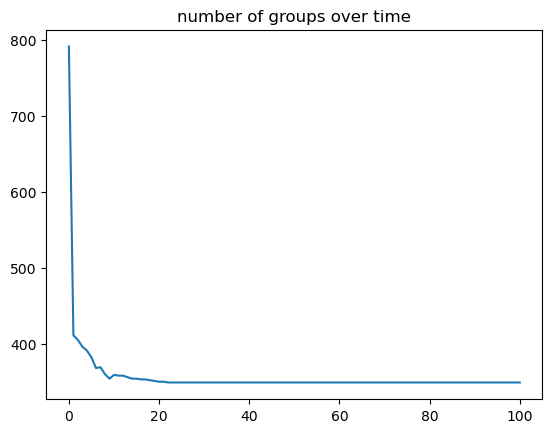

In [7]:
ng_t = [len(results['groups'][i]) for i in range(T+1)]

plt.plot(ng_t)
#plt.ylim(775,792)
plt.title('number of groups over time')
plt.show()

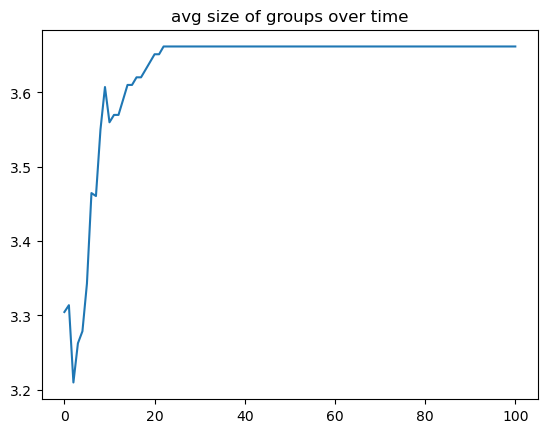

In [10]:
s_avg_t = []
for t in range(T+1):
    sizes_t = [len(group) for group in results['groups'][t]]
    s_avg_t.append(np.mean(sizes_t))
    
plt.plot(range(T+1), s_avg_t)
plt.title('avg size of groups over time')
plt.show()

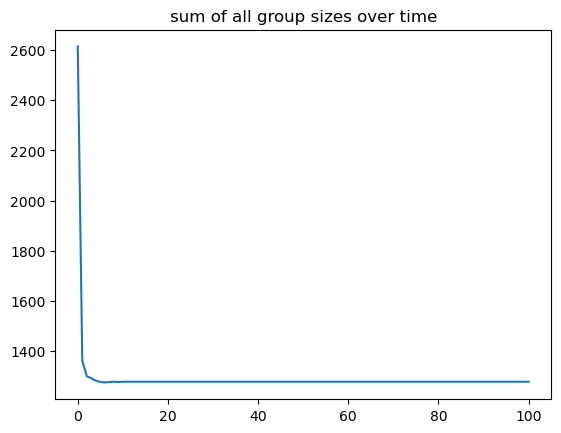

In [12]:
bb = np.array(ng_t) * np.array(s_avg_t)
plt.plot(bb)
#plt.xlim(-1,4)
#plt.ylim(2600,2620)
plt.title('sum of all group sizes over time')
plt.show()

# NOTE: This quantity is not conserved over time because initially there is more overlap between groups

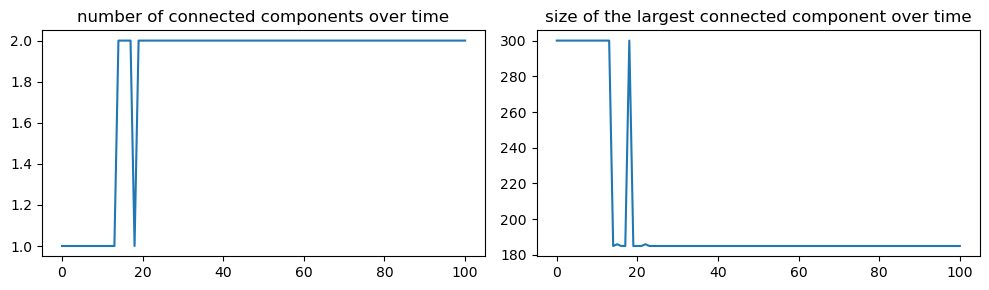

In [14]:
ncc = []
s_cc = []
for t in range(T+1):
    hedges = results['groups'][t]
    h = xgi.Hypergraph(hedges)
    # list of connected components
    cc = [j for j in xgi.connected_components(h)]
    ncc.append(len(cc))
    size_largest_cc = max([len(i) for i in cc])
    s_cc.append(size_largest_cc)

fig, axs = plt.subplots(1,2, figsize=(10,3))
axs[0].plot(ncc)
axs[0].set_title('number of connected components over time')
axs[1].plot(s_cc)
axs[1].set_title('size of the largest connected component over time')

plt.tight_layout()
plt.show()

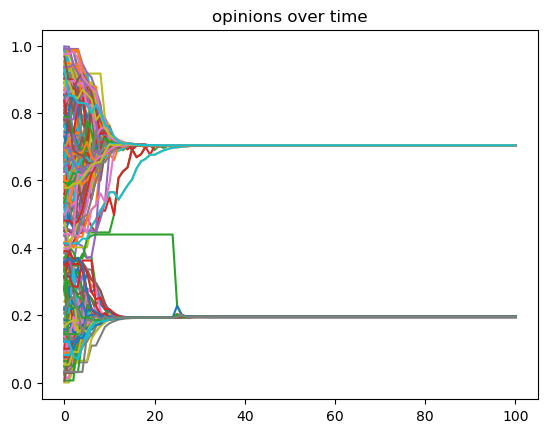

In [16]:
for n in H.nodes:
    plt.plot(results['opinions'][n])
plt.title('opinions over time')
plt.show()